# Exploración de Datos — Desconectados
## HackODS UNAM 2026 · Abejas Astutas

Análisis descriptivo y visualizaciones sobre los datos procesados por `01_procesar_datos.ipynb`.
Asume que `datos/estados.csv`, `datos/nacional.csv` y `datos/tendencia_abandono.csv` ya existen.

**Cadena causal del proyecto:**
> Pobreza extrema → Sin internet → Educación de menor calidad

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

# Paleta consistente con el dashboard
C_RED   = "#c0392b"
C_AMBER = "#d97706"
C_GREEN = "#15803d"
C_BLUE  = "#1d4ed8"
C_MUTED = "#64748b"

DATA = "../datos"

estados   = pd.read_csv(f"{DATA}/estados.csv")
nacional  = pd.read_csv(f"{DATA}/nacional.csv").iloc[0]
tendencia = pd.read_csv(f"{DATA}/tendencia_abandono.csv")

SUROESTE = [7, 12, 20]
NORTE    = [2,  5, 19]

print(f"Estados cargados:  {len(estados)}")
print(f"Media nacional:    {nacional['media_nacional']:.1f}%")
print(f"Brecha rural-urb:  {nacional['brecha_ur']:.1f} pp")

Estados cargados:  32
Media nacional:    73.6%
Brecha rural-urb:  31.2 pp


## 1 · Estadísticas descriptivas

In [2]:
desc = estados[["internet_pct","brecha","pobreza_pct",
                "pob_extrema_pct","titulados_pct","abandono_pct"]].describe().round(2)
print(desc.to_string())

print()
print("Correlaciones con la brecha digital (indicador central):")
for col in ["pobreza_pct","pob_extrema_pct","titulados_pct","abandono_pct"]:
    r = estados["brecha"].corr(estados[col])
    print(f"  brecha ↔ {col:<20} r = {r:+.3f}")

       internet_pct  brecha  pobreza_pct  pob_extrema_pct  titulados_pct  abandono_pct
count         32.00   32.00        32.00            32.00          32.00         32.00
mean          73.11   26.89        42.05             8.32          12.46          9.31
std            9.10    9.10        14.38             7.12           7.28          2.64
min           50.70   15.60        19.70             1.50           3.96          4.68
25%           66.55   19.48        29.95             3.50           6.34          7.66
50%           75.10   24.90        44.15             5.10          10.74          9.26
75%           80.53   33.45        51.25            10.05          18.76         11.17
max           84.40   49.30        74.40            28.30          27.84         15.72

Correlaciones con la brecha digital (indicador central):
  brecha ↔ pobreza_pct          r = +0.815
  brecha ↔ pob_extrema_pct      r = +0.804
  brecha ↔ titulados_pct        r = -0.383
  brecha ↔ abandono_pct       

## 2 · La cadena causal — cifras para público general

Traducción de los datos a lenguaje accesible para cualquier persona.

In [3]:
sur = estados[estados["CVE_ENT"].isin(SUROESTE)]
nor = estados[estados["CVE_ENT"].isin(NORTE)]

print("=" * 62)
print("ESLABÓN 1 · ECONOMÍA  (el contexto estructural)")
print("=" * 62)
sur_ext = sur["pob_extrema_pct"].mean()
nac_ext = estados["pob_extrema_pct"].mean()
print(f"  Pobreza extrema suroeste : {sur_ext:.1f}%")
print(f"  Pobreza extrema nacional : {nac_ext:.1f}%")
print(f"  → Casi 1 de cada 4 personas en el suroeste vive en pobreza extrema")
print(f"  → {sur['pob_extrema_abs'].sum():,.0f} personas en condición crítica")

print()
print("=" * 62)
print("ESLABÓN 2 · INFRAESTRUCTURA DIGITAL  (la brecha)")
print("=" * 62)
sur_br = sur["brecha"].mean()
nac_br = estados["brecha"].mean()
print(f"  Sin internet suroeste : {sur_br:.1f}%")
print(f"  Sin internet nacional : {nac_br:.1f}%")
print(f"  → Casi 1 de cada 2 hogares en el suroeste no tiene internet")
print(f"  → {sur['personas_sin_internet'].sum():,.0f} personas desconectadas")
print(f"  → {sur['personas_sin_internet'].sum() / estados['personas_sin_internet'].sum()*100:.1f}%"
      f" del total nacional de personas sin internet")

print()
print("=" * 62)
print("ESLABÓN 3 · CALIDAD EDUCATIVA  (la consecuencia)")
print("=" * 62)
sur_tit = sur["titulados_pct"].mean()
nor_tit = nor["titulados_pct"].mean()
nac_tit = estados["titulados_pct"].mean()
print(f"  Titulación suroeste : {sur_tit:.1f}%")
print(f"  Titulación nacional : {nac_tit:.1f}%")
print(f"  Titulación norte    : {nor_tit:.1f}%")
print(f"  → De cada 100 que TERMINAN el bachillerato en el suroeste,")
print(f"    solo {sur_tit:.0f} obtienen su título formal")
print(f"    (vs {nor_tit:.0f} en el norte · {nac_tit:.0f} promedio nacional)")
print(f"  → Brecha de calidad: {nor_tit/sur_tit:.1f}x más titulados en el norte")

ESLABÓN 1 · ECONOMÍA  (el contexto estructural)
  Pobreza extrema suroeste : 26.5%
  Pobreza extrema nacional : 8.3%
  → Casi 1 de cada 4 personas en el suroeste vive en pobreza extrema
  → 3,568,826 personas en condición crítica

ESLABÓN 2 · INFRAESTRUCTURA DIGITAL  (la brecha)
  Sin internet suroeste : 45.0%
  Sin internet nacional : 26.9%
  → Casi 1 de cada 2 hogares en el suroeste no tiene internet
  → 6,098,782 personas desconectadas
  → 17.8% del total nacional de personas sin internet

ESLABÓN 3 · CALIDAD EDUCATIVA  (la consecuencia)
  Titulación suroeste : 5.2%
  Titulación nacional : 12.5%
  Titulación norte    : 18.6%
  → De cada 100 que TERMINAN el bachillerato en el suroeste,
    solo 5 obtienen su título formal
    (vs 19 en el norte · 12 promedio nacional)
  → Brecha de calidad: 3.6x más titulados en el norte


## 3 · Visualización: los tres eslabones

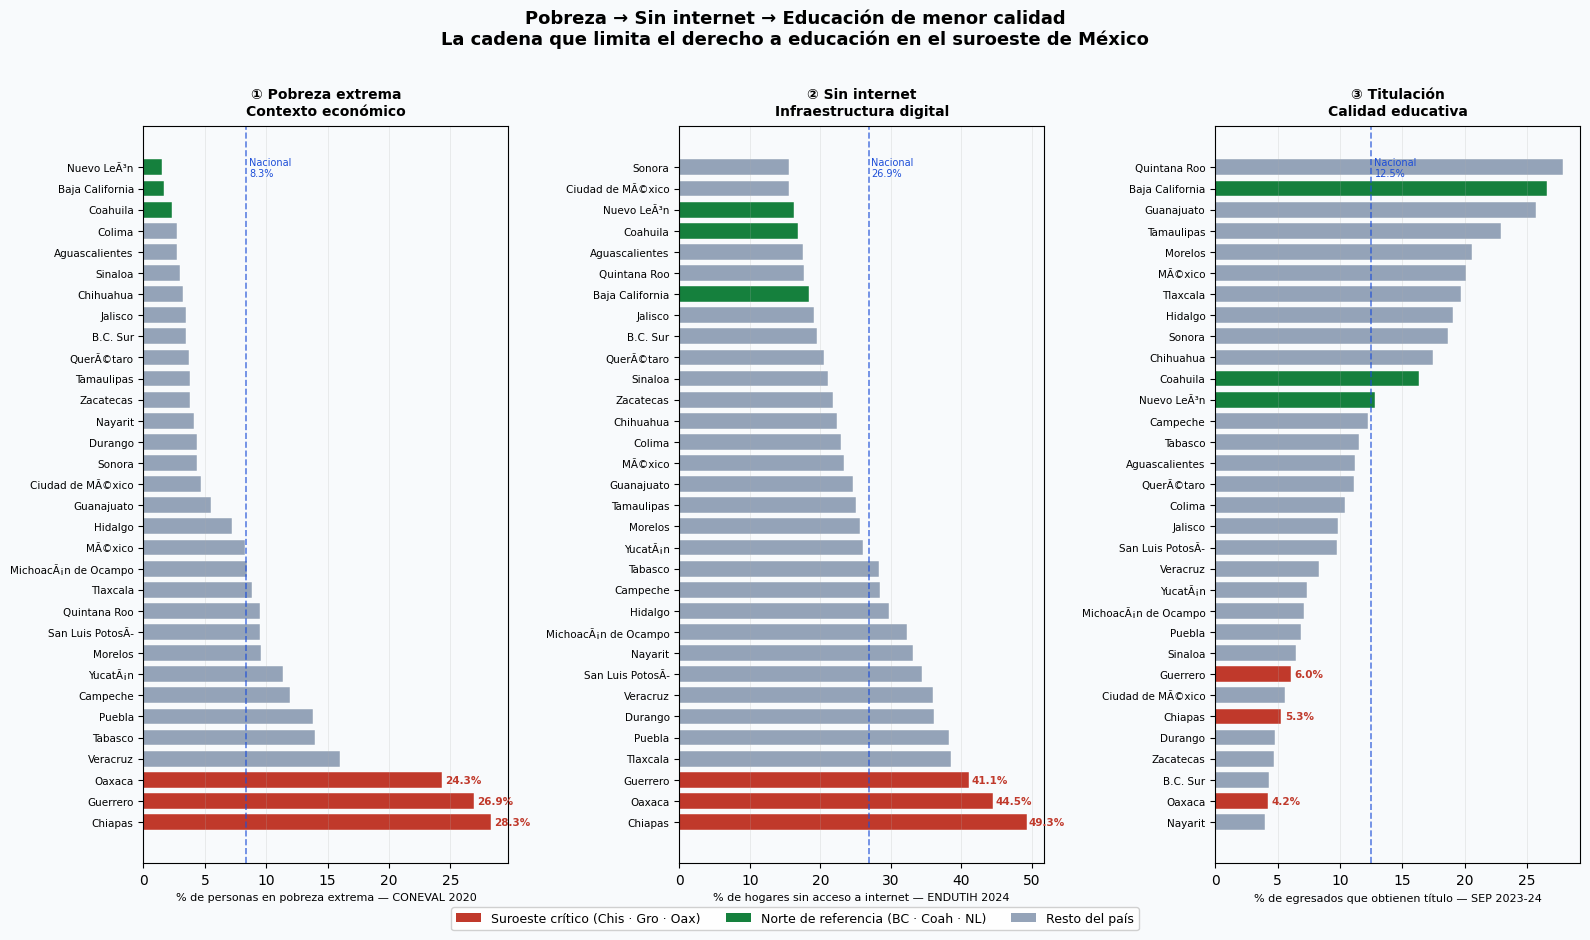

✔  fig_cadena_causal.png


In [4]:
def color_estado(cve):
    if cve in SUROESTE: return C_RED
    if cve in NORTE:    return C_GREEN
    return "#94a3b8"

fig, axes = plt.subplots(1, 3, figsize=(16, 9))
fig.patch.set_facecolor("#f8fafc")

indicadores = [
    ("pob_extrema_pct", "① Pobreza extrema",     "Contexto económico",
     "% de personas en pobreza extrema — CONEVAL 2020"),
    ("brecha",          "② Sin internet",         "Infraestructura digital",
     "% de hogares sin acceso a internet — ENDUTIH 2024"),
    ("titulados_pct",   "③ Titulación",           "Calidad educativa",
     "% de egresados que obtienen título — SEP 2023-24"),
]

for ax, (col, titulo, subtitulo, xlabel) in zip(axes, indicadores):
    # Para titulacion ordenar ascendente (peor = más a la izquierda)
    asc = (col == "titulados_pct")
    df_p = estados.sort_values(col, ascending=asc)
    colores = df_p["CVE_ENT"].apply(color_estado)

    bars = ax.barh(df_p["nombre"], df_p[col],
                   color=colores, height=0.75,
                   edgecolor="white", linewidth=0.3)

    media = estados[col].mean()
    ax.axvline(media, color=C_BLUE, linestyle="--", linewidth=1.2, alpha=0.7)
    ax.text(media + 0.3, 31.5, f"Nacional\n{media:.1f}%",
            color=C_BLUE, fontsize=7, va="top")

    # Etiquetas solo para suroeste
    for bar, (_, row) in zip(bars, df_p.iterrows()):
        if row["CVE_ENT"] in SUROESTE:
            ax.text(row[col] + 0.3, bar.get_y() + bar.get_height()/2,
                    f"{row[col]:.1f}%",
                    va="center", fontsize=7.5, color=C_RED, fontweight="bold")

    ax.set_title(f"{titulo}\n{subtitulo}", fontsize=10, fontweight="bold", pad=8)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_facecolor("#f8fafc")
    ax.tick_params(axis="y", labelsize=7.5)
    ax.grid(axis="x", alpha=0.3, linewidth=0.5)

fig.legend(
    handles=[
        Patch(facecolor=C_RED,    label="Suroeste crítico (Chis · Gro · Oax)"),
        Patch(facecolor=C_GREEN,  label="Norte de referencia (BC · Coah · NL)"),
        Patch(facecolor="#94a3b8",label="Resto del país"),
    ],
    loc="lower center", ncol=3, fontsize=9,
    framealpha=0.9, bbox_to_anchor=(0.5, -0.02)
)
fig.suptitle(
    "Pobreza → Sin internet → Educación de menor calidad\n"
    "La cadena que limita el derecho a educación en el suroeste de México",
    fontsize=13, fontweight="bold", y=1.01
)

plt.tight_layout()
plt.savefig(f"{DATA}/../scripts/fig_cadena_causal.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  fig_cadena_causal.png")

## 4 · Scatter: brecha digital vs calidad educativa

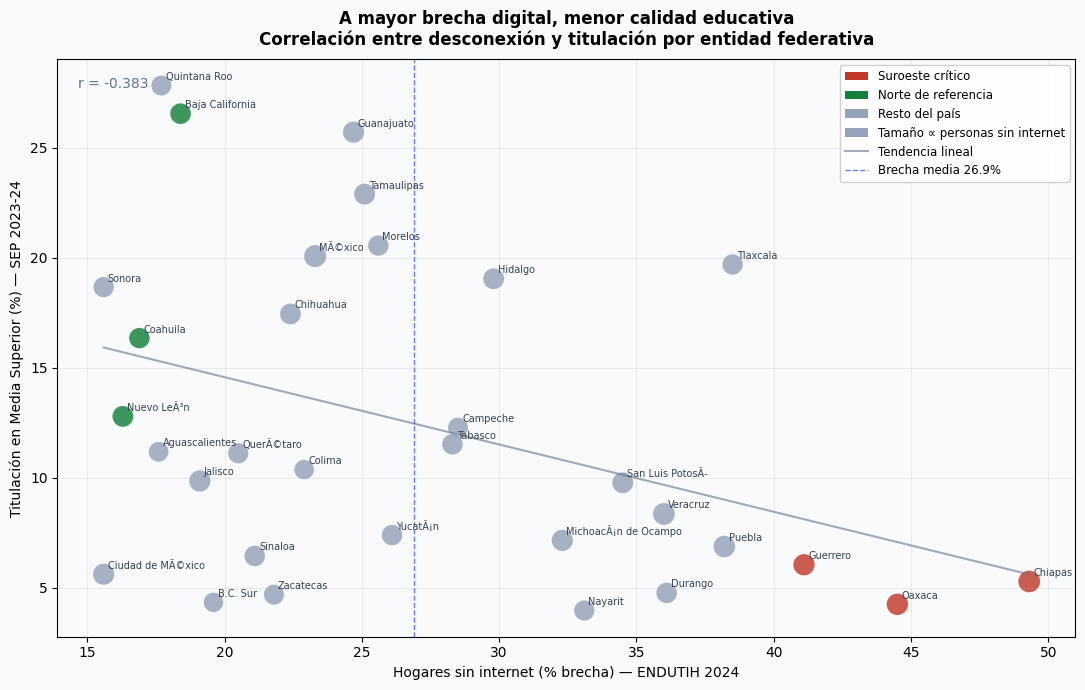

✔  fig_scatter_calidad.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor("#f8fafc")

df_sc = estados.dropna(subset=["titulados_pct","personas_sin_internet"])

# Burbuja proporcional a personas sin internet (log para suavizar outliers)
burbuja = np.log1p(df_sc["personas_sin_internet"]) * 18
colores_sc = df_sc["CVE_ENT"].apply(color_estado)

ax.scatter(
    df_sc["brecha"], df_sc["titulados_pct"],
    c=colores_sc, s=burbuja, alpha=0.82,
    edgecolors="white", linewidths=0.8
)

for _, row in df_sc.iterrows():
    ax.annotate(row["nombre"],
                (row["brecha"], row["titulados_pct"]),
                xytext=(3, 4), textcoords="offset points",
                fontsize=7, color="#374151")

# Línea de tendencia
m, b = np.polyfit(df_sc["brecha"], df_sc["titulados_pct"], 1)
x_line = np.linspace(df_sc["brecha"].min(), df_sc["brecha"].max(), 100)
ax.plot(x_line, m*x_line + b, color=C_MUTED, linestyle="-",
        linewidth=1.5, alpha=0.6, label="Tendencia lineal")

ax.axvline(estados["brecha"].mean(), color=C_BLUE, linestyle="--",
           linewidth=1, alpha=0.7,
           label=f"Brecha media {estados['brecha'].mean():.1f}%")

r = df_sc["brecha"].corr(df_sc["titulados_pct"])
ax.text(0.02, 0.97, f"r = {r:.3f}",
        transform=ax.transAxes, fontsize=10,
        color=C_MUTED, va="top")

ax.legend(handles=[
    Patch(facecolor=C_RED,    label="Suroeste crítico"),
    Patch(facecolor=C_GREEN,  label="Norte de referencia"),
    Patch(facecolor="#94a3b8",label="Resto del país"),
    Patch(facecolor="#94a3b8",label="Tamaño ∝ personas sin internet"),
    ax.lines[0], ax.lines[1],
], fontsize=8.5, framealpha=0.9, loc="upper right")

ax.set_xlabel("Hogares sin internet (% brecha) — ENDUTIH 2024", fontsize=10)
ax.set_ylabel("Titulación en Media Superior (%) — SEP 2023-24", fontsize=10)
ax.set_title(
    "A mayor brecha digital, menor calidad educativa\n"
    "Correlación entre desconexión y titulación por entidad federativa",
    fontsize=12, fontweight="bold", pad=10
)
ax.set_facecolor("#f8fafc")
ax.grid(alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig(f"{DATA}/../scripts/fig_scatter_calidad.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  fig_scatter_calidad.png")

## 5 · Tendencia histórica de abandono escolar

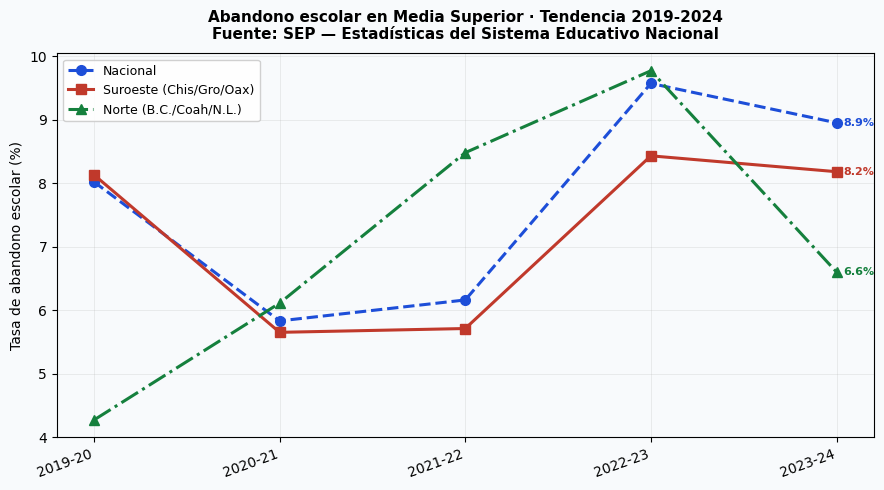

✔  fig_tendencia_abandono.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#f8fafc")

series_config = {
    "Nacional":                 (C_BLUE,  "--", "o"),
    "Suroeste (Chis/Gro/Oax)": (C_RED,   "-",  "s"),
    "Norte (B.C./Coah/N.L.)":  (C_GREEN, "-.", "^"),
}
etiquetas_x = {2020:"2019-20", 2021:"2020-21", 2022:"2021-22",
               2023:"2022-23", 2024:"2023-24"}

for serie, (color, ls, marker) in series_config.items():
    ax.plot(tendencia["anio"], tendencia[serie],
            color=color, linestyle=ls, marker=marker,
            linewidth=2.2, markersize=7, label=serie)
    last = tendencia[serie].iloc[-1]
    ax.annotate(f"{last:.1f}%", (2024, last),
                xytext=(5, 0), textcoords="offset points",
                color=color, fontsize=8, va="center", fontweight="bold")

ax.set_xticks(tendencia["anio"])
ax.set_xticklabels(list(etiquetas_x.values()), rotation=20, ha="right")
ax.set_ylabel("Tasa de abandono escolar (%)", fontsize=10)
ax.set_title(
    "Abandono escolar en Media Superior · Tendencia 2019-2024\n"
    "Fuente: SEP — Estadísticas del Sistema Educativo Nacional",
    fontsize=11, fontweight="bold", pad=10
)
ax.legend(fontsize=9, framealpha=0.9)
ax.set_facecolor("#f8fafc")
ax.grid(alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig(f"{DATA}/../scripts/fig_tendencia_abandono.png", dpi=130, bbox_inches="tight")
plt.show()
print("✔  fig_tendencia_abandono.png")

## 6 · Abandono escolar: absoluto vs tasa por 100k habitantes

Muestra **por qué normalizar por población estatal es necesario**: estados pequeños
con alta tasa pueden tener menos alumnos afectados en absoluto que estados grandes
con tasa baja.

In [7]:
# abandono_x100k: personas por cada 100,000 habitantes
estados["abandono_x100k"] = (
    estados["alumnos_abandono_abs"] / estados["pob_total"] * 100_000
).round(1)

df_comp = estados[["nombre","abandono_pct","alumnos_abandono_abs",
                    "abandono_x100k","pob_total"]].copy()
df_comp = df_comp.sort_values("abandono_x100k", ascending=False)

print("Abandono escolar ordenado por tasa por 100k hab:")
print(df_comp.to_string(index=False))

print()
print("═" * 55)
print("SUROESTE (Chiapas, Guerrero, Oaxaca)")
sur_c = df_comp[df_comp["nombre"].isin(["Chiapas","Guerrero","Oaxaca"])]
print(f"  Personas que abandonaron : {estados[estados['CVE_ENT'].isin(SUROESTE)]['alumnos_abandono_abs'].sum():,.0f}")
print(f"  Abandono x100k (promedio): {estados[estados['CVE_ENT'].isin(SUROESTE)]['abandono_x100k'].mean():.1f}")
print()
print("NORTE (B.C., Coahuila, Nuevo León)")
print(f"  Personas que abandonaron : {estados[estados['CVE_ENT'].isin(NORTE)]['alumnos_abandono_abs'].sum():,.0f}")
print(f"  Abandono x100k (promedio): {estados[estados['CVE_ENT'].isin(NORTE)]['abandono_x100k'].mean():.1f}")

Abandono escolar ordenado por tasa por 100k hab:
              nombre  abandono_pct  alumnos_abandono_abs  abandono_x100k  pob_total
   Ciudad de MÃ©xico          9.79                 62296           714.3  8721320.0
            B.C. Sur         15.72                  6044           682.6   885465.0
            YucatÃ¡n         13.06                 12800           566.5  2259381.0
             Morelos         13.22                 11004           540.3  2036707.0
          QuerÃ©taro         11.85                 11438           530.6  2155802.0
          Guanajuato         11.54                 29486           487.8  6045151.0
             Nayarit         11.33                  6505           485.3  1340427.0
           Zacatecas         11.91                  7937           484.9  1636983.0
             Durango         10.81                  8680           468.6  1852264.0
              Sonora         11.12                 14528           463.2  3136574.0
          Tamaulipas       